In [1]:
import os
import gc
import json
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.utils import resample
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, precision_score
# --- CONFIGURAÇÕES --
PASTAS_DATASET = [
    'imagens_acrais_benignas',
    'imagens_acrais_maligno'
]

CAMINHO_MODELOS = 'Modelos'



I0000 00:00:1778165845.798198    1293 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Permite que o TF aloque memória gradualmente conforme a necessidade
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Erro na config da GPU: {e}")

In [2]:
# Definir Presets
TAMANHO_IMAGEM = (224, 224)

# CARREGAR E COMBINAR METADADOS ---
dfs = []
for pasta in PASTAS_DATASET:
    caminho_csv = os.path.join(pasta, 'metadata.csv')
    if os.path.exists(caminho_csv):
        df_temp = pd.read_csv(caminho_csv)
        # Cria uma nova coluna com o caminho completo da imagem para facilitar
        df_temp['caminho_imagem'] = df_temp['isic_id'].apply(lambda x: os.path.join(pasta, f"{x}.jpg"))
        dfs.append(df_temp)
    else:
        print(f"Aviso: {caminho_csv} não encontrado.")

# Junta os CSVs das duas pastas em um só DataFrame
df_completo = pd.concat(dfs, ignore_index=True)

# FILTRAR DATASET (Usando todas as imagens disponíveis) ---
## 1. Primeiro, removemos duplicatas baseadas no ID único e verificamos existência física
df_unico = df_completo.drop_duplicates(subset='isic_id')
df_existente = df_unico[df_unico['caminho_imagem'].apply(os.path.exists)].copy()

## 2. Separar as classes sem limite de amostras
df_benigno = df_existente[df_existente['diagnosis_1'] == 'Benign']
df_maligno = df_existente[df_existente['diagnosis_1'] == 'Malignant']

## 3. Combinar e embaralhar o dataset final com tudo que foi encontrado
df_filtrado = pd.concat([df_benigno, df_maligno]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset total criado com {len(df_filtrado)} imagens (Benignas: {len(df_benigno)}, Malignas: {len(df_maligno)}).")

Dataset total criado com 2059 imagens (Benignas: 1557, Malignas: 502).


In [3]:
print("=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===")

TAMANHO_B0 = (224, 224)
BATCH_SIZE = 32

# Validação: 20% do df_filtrado, sem augmentation (métricas mais estáveis)
datagen_val = ImageDataGenerator(validation_split=0.2)
val_gen = datagen_val.flow_from_dataframe(
    dataframe=df_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Oversampling da classe minoritária até igualar a majoritária
df_malignant = df_filtrado[df_filtrado["diagnosis_1"] == "Malignant"]
df_benign = df_filtrado[df_filtrado["diagnosis_1"] == "Benign"]
maior_classe = max(len(df_malignant), len(df_benign))
df_benign_upsampled = resample(
    df_benign, replace=True, n_samples=maior_classe, random_state=42
)
df_malignant_upsampled = resample(
    df_malignant, replace=True, n_samples=maior_classe, random_state=42
)
df_equilibrado = pd.concat([df_malignant_upsampled, df_benign_upsampled]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"Treino equilibrado: {len(df_equilibrado)} imagens")
print(df_equilibrado["diagnosis_1"].value_counts())

datagen_balanced = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=45,       # Rotação padrão (o artigo não especifica 360, então usamos um valor moderado comum)
    width_shift_range=0.1,   # Translações horizontais
    height_shift_range=0.1,  # Translações verticais
    horizontal_flip=True,    # Flips aleatórios
    vertical_flip=True       # Flips aleatórios
    # Sem zoom, sem alteração de cor, sem shear.
)

train_gen_balanced = datagen_balanced.flow_from_dataframe(
    dataframe=df_equilibrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===
Found 411 validated image filenames belonging to 2 classes.
Treino equilibrado: 3114 imagens
diagnosis_1
Malignant    1557
Benign       1557
Name: count, dtype: int64
Found 3114 validated image filenames belonging to 2 classes.


In [ ]:
# === GRID SEARCH (6 TESTES: 2 LRs x 3 nº de camadas/blocos descongelados) ===
# Variamos:
#   - Taxa de aprendizado (LR): 1e-4, 1e-5
#   - Nº de blocos do EfficientNetB0 descongelados (a partir do topo): 1, 2, 3
#       * 1 -> apenas block7 + camadas top_*
#       * 2 -> blocks 6 e 7 + top_*
#       * 3 -> blocks 5, 6 e 7 + top_*
#   - Dropout fixo em 0.4 (para isolar o efeito das duas variáveis estudadas)

os.makedirs(CAMINHO_MODELOS, exist_ok=True)

learning_rates       = [1e-4, 1e-5]
unfrozen_blocks_list = [1, 2, 3]
DROPOUT              = 0.4

historicos_grid = {}


def descongelar_ultimos_n_blocos(base_model, n_blocos):
    """Congela toda a base e descongela os últimos n blocos (block{7-n+1}..block7)
    junto com as camadas finais (top_*). Mantém BatchNorm congelado, prática usual
    em fine-tuning de EfficientNet."""
    base_model.trainable = False
    blocos_descongelar = set(range(7 - n_blocos + 1, 8))  # ex.: n=2 -> {6,7}
    for layer in base_model.layers:
        deve_descongelar = (
            any(layer.name.startswith(f"block{b}") for b in blocos_descongelar)
            or layer.name.startswith("top_")
        )
        if deve_descongelar and not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False
    n_treinaveis = sum(int(np.prod(w.shape)) for w in base_model.trainable_weights)
    return n_treinaveis


print("=== INICIANDO GRID SEARCH (6 TESTES: LR x Nº camadas descongeladas) ===")

for lr in learning_rates:
    for n_unf in unfrozen_blocks_list:

        nome_teste   = f"LR{lr}_UL{n_unf}"
        nome_arquivo = os.path.join(CAMINHO_MODELOS, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"INICIANDO TESTE: {nome_teste}")
        print(f"Learning Rate: {lr} | Blocos descongelados: {n_unf} | Dropout: {DROPOUT}")
        print("=" * 60)

        # Limpa memória da GPU para evitar travamento entre testes
        tf.keras.backend.clear_session()
        gc.collect()

        # Monta a rede do zero
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3),
        )
        n_treinaveis = descongelar_ultimos_n_blocos(base_model, n_unf)
        print(f"Parâmetros treináveis na base (sem BN): {n_treinaveis:,}")

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(DROPOUT)(x)
        saida = Dense(1, activation="sigmoid")(x)
        modelo_cnn = Model(inputs=base_model.input, outputs=saida)

        modelo_cnn.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
        )

        callbacks_lista = [
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
            ModelCheckpoint(
                filepath=nome_arquivo,
                monitor="val_recall",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        ]

        print(f"Treinando modelo {nome_teste}...")
        history = modelo_cnn.fit(
            train_gen_balanced,
            validation_data=val_gen,
            epochs=20,
            callbacks=callbacks_lista,
            verbose=1,
        )
        historicos_grid[nome_teste] = history.history

# Persiste os históricos em disco para análises posteriores
with open(os.path.join(CAMINHO_MODELOS, "historicos_grid.json"), "w") as f:
    json.dump(
        {k: {m: list(map(float, v)) for m, v in h.items()} for k, h in historicos_grid.items()},
        f,
    )

print("\n✅ GRID SEARCH CONCLUÍDO COM SUCESSO!")
print(f"Os 6 arquivos .keras foram salvos em '{CAMINHO_MODELOS}/'.")

=== INICIANDO GRID SEARCH (6 TESTES) ===

INICIANDO TESTE: Modelos/LR0.0001_DO0.4
Taxa de Aprendizado: 0.0001 | Dropout: 0.4
Treinando modelo Modelos/LR0.0001_DO0.4...
Epoch 1/20


W0000 00:00:1778076457.234201   10772 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1778076458.506270   10771 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.


 2/98 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.5547 - loss: 0.7160 - recall: 0.5778   

W0000 00:00:1778076510.978715   10772 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.


29/98 ━━━━━━━━━━━━━━━━━━━━ 1:05 954ms/step - accuracy: 0.6942 - loss: 0.5883 - recall: 0.7174

E0000 00:00:1778076559.386507    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076561.252857    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076566.486461    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076574.368082    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076581.760132    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7912 - loss: 0.4403 - recall: 0.8159

E0000 00:00:1778076737.436754    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076739.407342    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076740.418704    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076742.958682    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_recall improved from None to 0.77551, saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras

Epoch 1: finished saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.8651 - loss: 0.3139 - recall: 0.8857 - val_accuracy: 0.9124 - val_loss: 0.1897 - val_recall: 0.7755 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.9422 - loss: 0.1514 - recall: 0.9569
Epoch 2: val_recall improved from 0.77551 to 0.97959, saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras

Epoch 2: finished saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9457 - loss: 0.1448 - recall: 0.9583 - val_accuracy: 0.9611 - val_loss: 0.0932 - val_recall: 0.9796 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9684 - loss: 0.0985 - recall: 0.9747   
Epoch 3: val_recall did not improve from 0.979

=== AVALIAÇÃO DOS MODELOS (GRID SEARCH) ===

📊 AVALIANDO MODELO: LR0.001_DO0.4

Relatório de Classificação (LR0.001_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9936    0.9968       313
   Malignant     0.9800    1.0000    0.9899        98

    accuracy                         0.9951       411
   macro avg     0.9900    0.9968    0.9933       411
weighted avg     0.9952    0.9951    0.9952       411



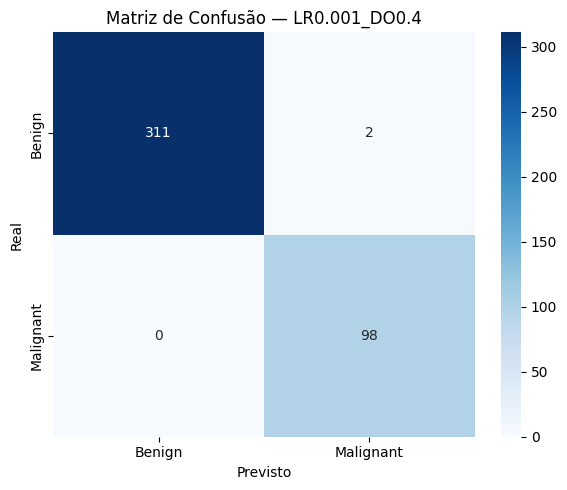


📊 AVALIANDO MODELO: LR0.001_DO0.5

Relatório de Classificação (LR0.001_DO0.5):
              precision    recall  f1-score   support

      Benign     1.0000    0.9872    0.9936       313
   Malignant     0.9608    1.0000    0.9800        98

    accuracy                         0.9903       411
   macro avg     0.9804    0.9936    0.9868       411
weighted avg     0.9906    0.9903    0.9903       411



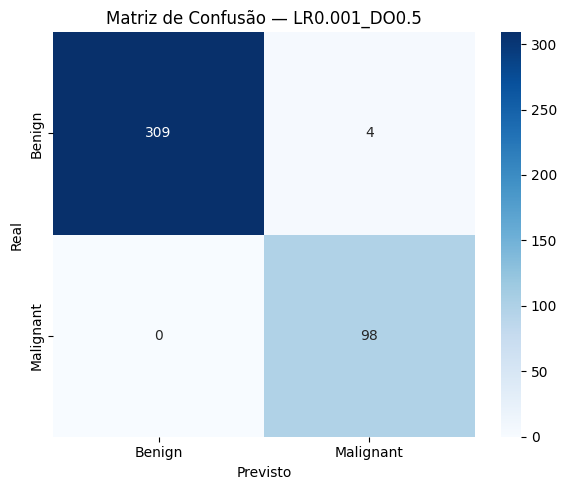


📊 AVALIANDO MODELO: LR0.0001_DO0.4

Relatório de Classificação (LR0.0001_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9936    0.9968       313
   Malignant     0.9800    1.0000    0.9899        98

    accuracy                         0.9951       411
   macro avg     0.9900    0.9968    0.9933       411
weighted avg     0.9952    0.9951    0.9952       411



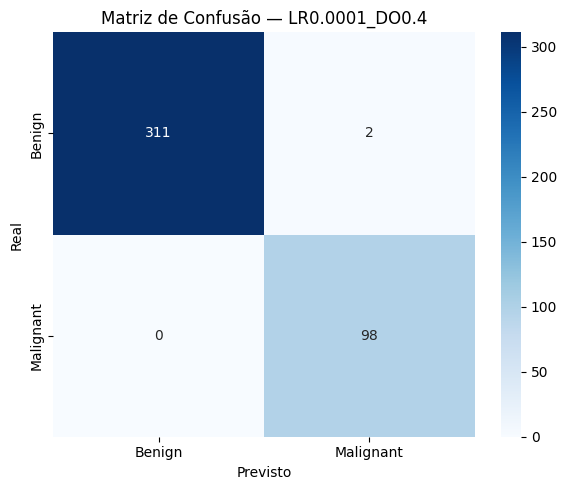


📊 AVALIANDO MODELO: LR0.0001_DO0.5

Relatório de Classificação (LR0.0001_DO0.5):
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000       313
   Malignant     1.0000    1.0000    1.0000        98

    accuracy                         1.0000       411
   macro avg     1.0000    1.0000    1.0000       411
weighted avg     1.0000    1.0000    1.0000       411



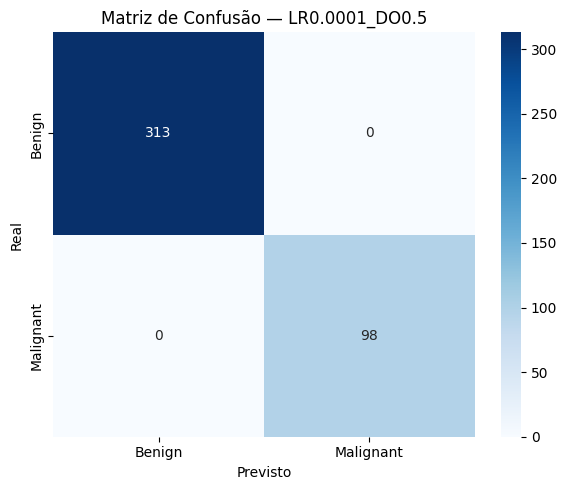


📊 AVALIANDO MODELO: LR1e-05_DO0.4

Relatório de Classificação (LR1e-05_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9233    0.9601       313
   Malignant     0.8033    1.0000    0.8909        98

    accuracy                         0.9416       411
   macro avg     0.9016    0.9617    0.9255       411
weighted avg     0.9531    0.9416    0.9436       411



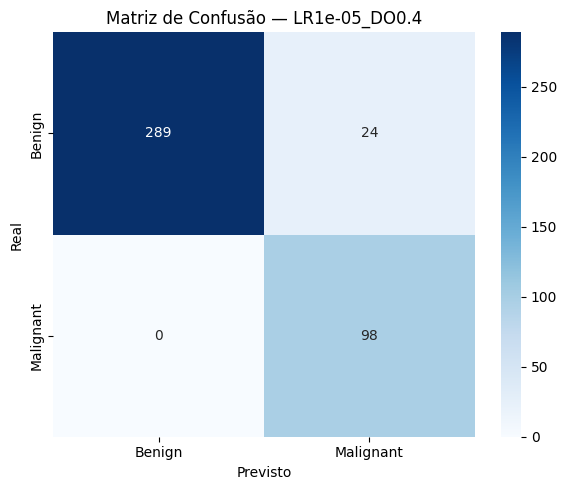


📊 AVALIANDO MODELO: LR1e-05_DO0.5

Relatório de Classificação (LR1e-05_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9965    0.9042    0.9481       313
   Malignant     0.7638    0.9898    0.8622        98

    accuracy                         0.9246       411
   macro avg     0.8801    0.9470    0.9051       411
weighted avg     0.9410    0.9246    0.9276       411



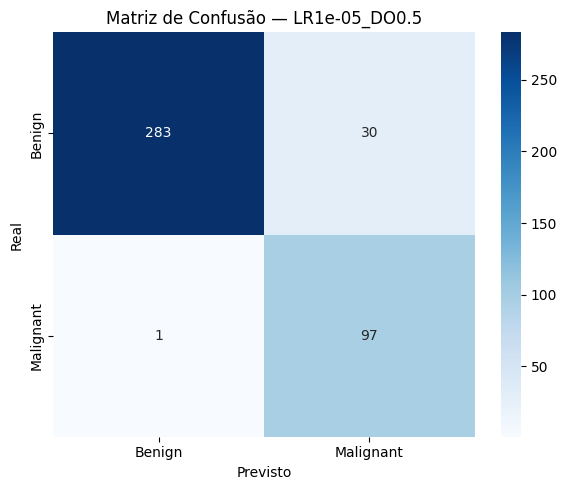

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

learning_rates       = [1e-4, 1e-5]
unfrozen_blocks_list = [1, 2, 3]

print("=== AVALIAÇÃO DOS 6 MODELOS NO CONJUNTO DE VALIDAÇÃO PADRÃO ===")

y_true       = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

PASTA_MODELOS = CAMINHO_MODELOS  # 'Modelos'

# Estrutura dos resultados: nome -> {acc, recall, lr, n_unf}
resultados_val = {}

for lr in learning_rates:
    for n_unf in unfrozen_blocks_list:
        nome_teste       = f"LR{lr}_UL{n_unf}"
        caminho_completo = os.path.join(PASTA_MODELOS, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"📊 AVALIANDO MODELO: {nome_teste}")
        print("=" * 60)

        if not os.path.exists(caminho_completo):
            print(f"⚠️  Arquivo não encontrado: {caminho_completo}")
            continue

        try:
            tf.keras.backend.clear_session()
            gc.collect()

            modelo_salvo = tf.keras.models.load_model(caminho_completo)

            val_gen.reset()
            y_prob = modelo_salvo.predict(val_gen, verbose=0).flatten()
            y_pred = (y_prob > 0.5).astype(int)

            acc = accuracy_score(y_true, y_pred)
            rec = recall_score(y_true, y_pred)
            resultados_val[nome_teste] = {
                "acc": acc,
                "recall": rec,
                "lr": lr,
                "n_unf": n_unf,
            }

            print(f"\nRelatório de Classificação ({nome_teste}):")
            print(classification_report(y_true, y_pred, target_names=class_labels, digits=4, zero_division=0))

            cm = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(6, 5))
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels,
            )
            plt.title(f"Matriz de Confusão — {nome_teste}\n(Validação padrão)")
            plt.ylabel("Real")
            plt.xlabel("Previsto")
            plt.tight_layout()
            plt.show()

            del modelo_salvo
            tf.keras.backend.clear_session()
            gc.collect()

        except (FileNotFoundError, ValueError) as e:
            print(f"⚠️  Falha ao carregar/avaliar {caminho_completo}: {e}")

# ========================================================================
# GRÁFICO COMPARATIVO: val_recall e acurácia x nº de blocos descongelados
# ========================================================================
if resultados_val:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for lr in learning_rates:
        xs       = [n for n in unfrozen_blocks_list if f"LR{lr}_UL{n}" in resultados_val]
        accs     = [resultados_val[f"LR{lr}_UL{n}"]["acc"]    for n in xs]
        recalls  = [resultados_val[f"LR{lr}_UL{n}"]["recall"] for n in xs]

        axes[0].plot(xs, accs,    marker="o", linewidth=2, label=f"LR = {lr:.0e}")
        axes[1].plot(xs, recalls, marker="o", linewidth=2, label=f"LR = {lr:.0e}")

    axes[0].set_title("Acurácia x Nº de blocos descongelados\n(Validação padrão)")
    axes[0].set_xlabel("Nº de blocos descongelados")
    axes[0].set_ylabel("Acurácia")
    axes[0].set_xticks(unfrozen_blocks_list)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Recall x Nº de blocos descongelados\n(Validação padrão)")
    axes[1].set_xlabel("Nº de blocos descongelados")
    axes[1].set_ylabel("Recall (sensibilidade p/ Malignant)")
    axes[1].set_xticks(unfrozen_blocks_list)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Tabela-resumo
    df_resumo_val = pd.DataFrame([
        {"modelo": nome, "lr": d["lr"], "blocos_descongelados": d["n_unf"],
         "acuracia": d["acc"], "recall": d["recall"]}
        for nome, d in resultados_val.items()
    ]).sort_values(["lr", "blocos_descongelados"]).reset_index(drop=True)
    print("\nResumo (Validação padrão):")
    print(df_resumo_val.to_string(index=False))
else:
    print("⚠️  Nenhum modelo avaliado. Verifique se os arquivos .keras existem.")

In [5]:
# === PREPARAÇÃO DO DATASET DE TESTE: ISIC-images ===
print("=== PREPARANDO DATASET DE TESTE: ISIC-images ===\n")

PASTA_ISIC = 'ISIC-images'

# Carrega os metadados do dataset ISIC-images
df_isic = pd.read_csv(os.path.join(PASTA_ISIC, 'metadata.csv'))

# Cria coluna com o caminho completo de cada imagem
df_isic['caminho_imagem'] = df_isic['isic_id'].apply(
    lambda x: os.path.join(PASTA_ISIC, f"{x}.jpg")
)

# Remove duplicatas por isic_id
df_isic = df_isic.drop_duplicates(subset='isic_id')

# Verifica existência física das imagens no disco
df_isic = df_isic[df_isic['caminho_imagem'].apply(os.path.exists)].copy()

# Filtra apenas as classes de interesse (Benign e Malignant)
df_isic_filtrado = df_isic[df_isic['diagnosis_1'].isin(['Benign', 'Malignant'])].copy()
df_isic_filtrado = df_isic_filtrado.reset_index(drop=True)

# Estatísticas do dataset organizado
n_total    = len(df_isic_filtrado)
n_benign   = len(df_isic_filtrado[df_isic_filtrado['diagnosis_1'] == 'Benign'])
n_malignant = len(df_isic_filtrado[df_isic_filtrado['diagnosis_1'] == 'Malignant'])

print(f"Dataset ISIC-images organizado com sucesso!")
print(f"  Total de imagens : {n_total}")
print(f"  Benignas         : {n_benign}")
print(f"  Malignas         : {n_malignant}")
print(f"\nDistribuição das classes:")
print(df_isic_filtrado['diagnosis_1'].value_counts())


=== PREPARANDO DATASET DE TESTE: ISIC-images ===

Dataset ISIC-images organizado com sucesso!
  Total de imagens : 666
  Benignas         : 522
  Malignas         : 144

Distribuição das classes:
diagnosis_1
Benign       522
Malignant    144
Name: count, dtype: int64


=== TESTANDO OS 6 MODELOS NO DATASET ISIC-IMAGES ===

Found 666 validated image filenames belonging to 2 classes.


Mapeamento de classes : {'Benign': 0, 'Malignant': 1}
Total de amostras     : 666


📊  AVALIANDO MODELO: LR0.001_DO0.4
21/21 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step

Relatório de Classificação (LR0.001_DO0.4):
              precision    recall  f1-score   support

      Benign     0.8899    0.9598    0.9235       522
   Malignant     0.7961    0.5694    0.6640       144

    accuracy                         0.8754       666
   macro avg     0.8430    0.7646    0.7937       666
weighted avg     0.8696    0.8754    0.8674       666



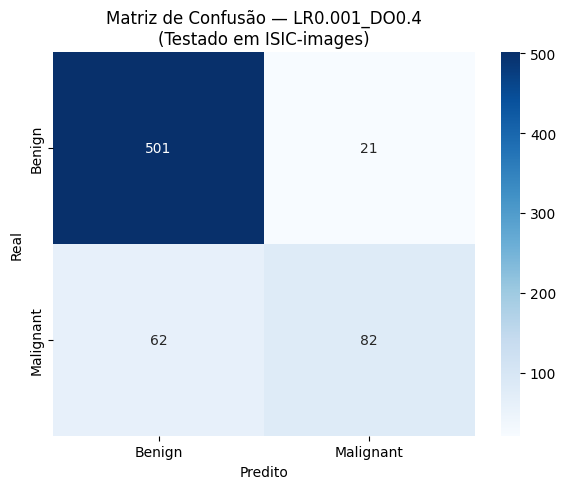


📊  AVALIANDO MODELO: LR0.001_DO0.5
21/21 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step

Relatório de Classificação (LR0.001_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9315    0.8333    0.8797       522
   Malignant     0.5628    0.7778    0.6531       144

    accuracy                         0.8213       666
   macro avg     0.7471    0.8056    0.7664       666
weighted avg     0.8518    0.8213    0.8307       666



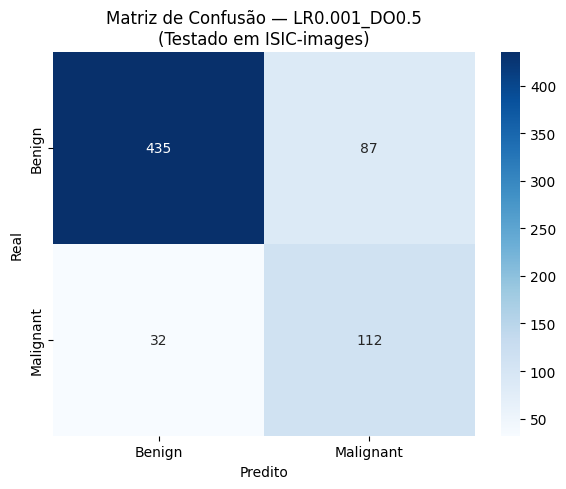


📊  AVALIANDO MODELO: LR0.0001_DO0.4
21/21 ━━━━━━━━━━━━━━━━━━━━ 167s 8s/step

Relatório de Classificação (LR0.0001_DO0.4):
              precision    recall  f1-score   support

      Benign     0.9123    0.9368    0.9244       522
   Malignant     0.7462    0.6736    0.7080       144

    accuracy                         0.8799       666
   macro avg     0.8292    0.8052    0.8162       666
weighted avg     0.8764    0.8799    0.8776       666



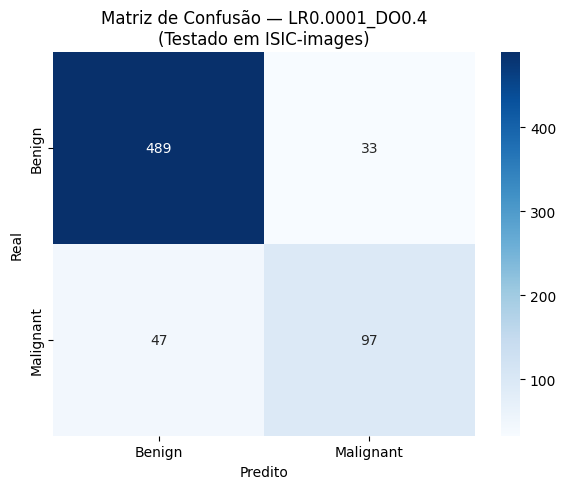


📊  AVALIANDO MODELO: LR0.0001_DO0.5
21/21 ━━━━━━━━━━━━━━━━━━━━ 157s 7s/step

Relatório de Classificação (LR0.0001_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9227    0.9598    0.9408       522
   Malignant     0.8293    0.7083    0.7640       144

    accuracy                         0.9054       666
   macro avg     0.8760    0.8341    0.8524       666
weighted avg     0.9025    0.9054    0.9026       666



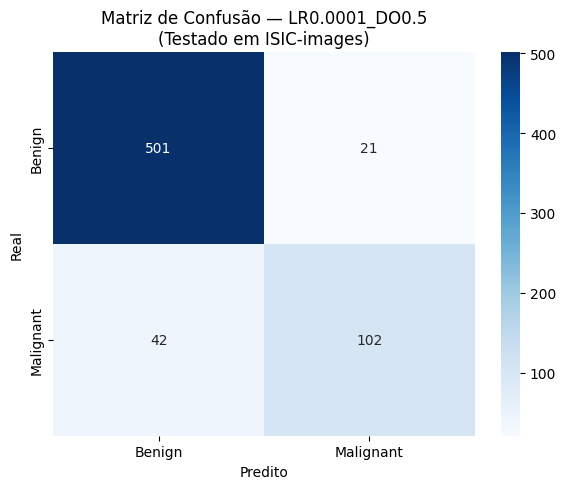


📊  AVALIANDO MODELO: LR1e-05_DO0.4
21/21 ━━━━━━━━━━━━━━━━━━━━ 166s 8s/step

Relatório de Classificação (LR1e-05_DO0.4):
              precision    recall  f1-score   support

      Benign     0.9400    0.8697    0.9035       522
   Malignant     0.6284    0.7986    0.7034       144

    accuracy                         0.8544       666
   macro avg     0.7842    0.8342    0.8034       666
weighted avg     0.8726    0.8544    0.8602       666



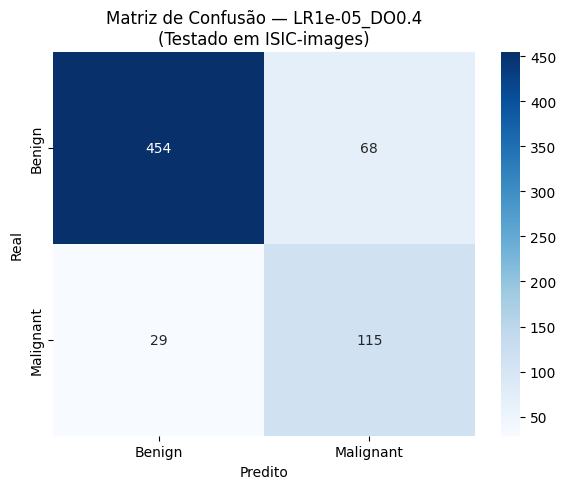


📊  AVALIANDO MODELO: LR1e-05_DO0.5
21/21 ━━━━━━━━━━━━━━━━━━━━ 160s 7s/step

Relatório de Classificação (LR1e-05_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9415    0.8640    0.9011       522
   Malignant     0.6203    0.8056    0.7009       144

    accuracy                         0.8514       666
   macro avg     0.7809    0.8348    0.8010       666
weighted avg     0.8721    0.8514    0.8578       666



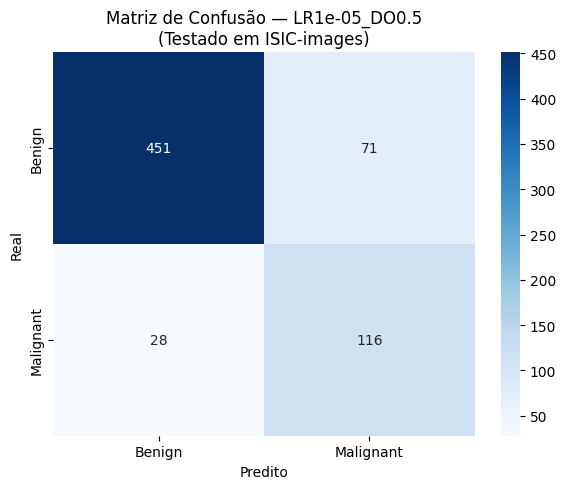


✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!

🏆 Melhor modelo (acurácia em ISIC-images): LR0.0001_DO0.5
   Acurácia: 0.9054
21/21 ━━━━━━━━━━━━━━━━━━━━ 165s 8s/step

5 imagens classificadas ERRADO (LR0.0001_DO0.5):
  ISIC-images/ISIC_7272864.jpg
  ISIC-images/ISIC_4231556.jpg
  ISIC-images/ISIC_6047744.jpg
  ISIC-images/ISIC_0713136.jpg
  ISIC-images/ISIC_9620217.jpg


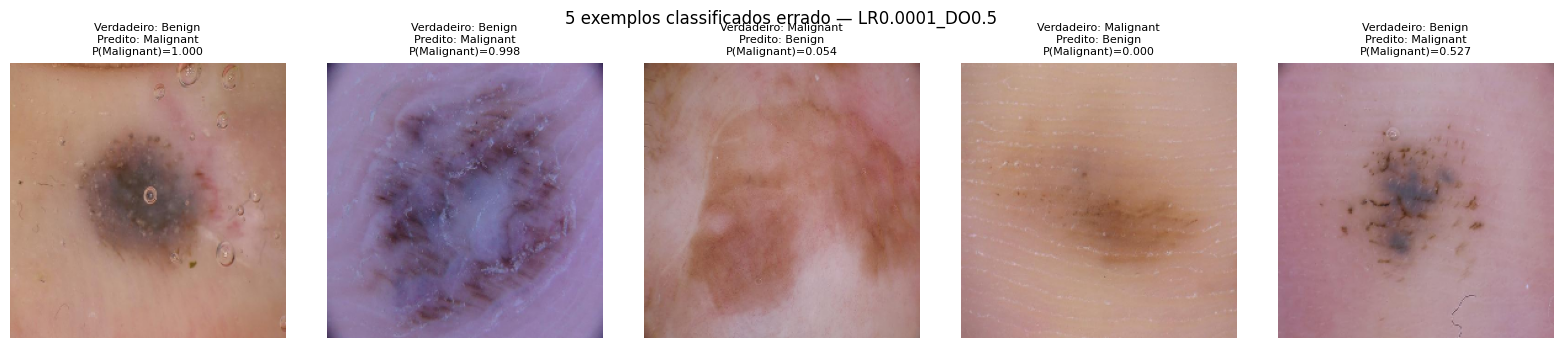


5 imagens classificadas CERTO (LR0.0001_DO0.5):
  ISIC-images/ISIC_9725825.jpg
  ISIC-images/ISIC_1194491.jpg
  ISIC-images/ISIC_5643394.jpg
  ISIC-images/ISIC_7645973.jpg
  ISIC-images/ISIC_7505287.jpg


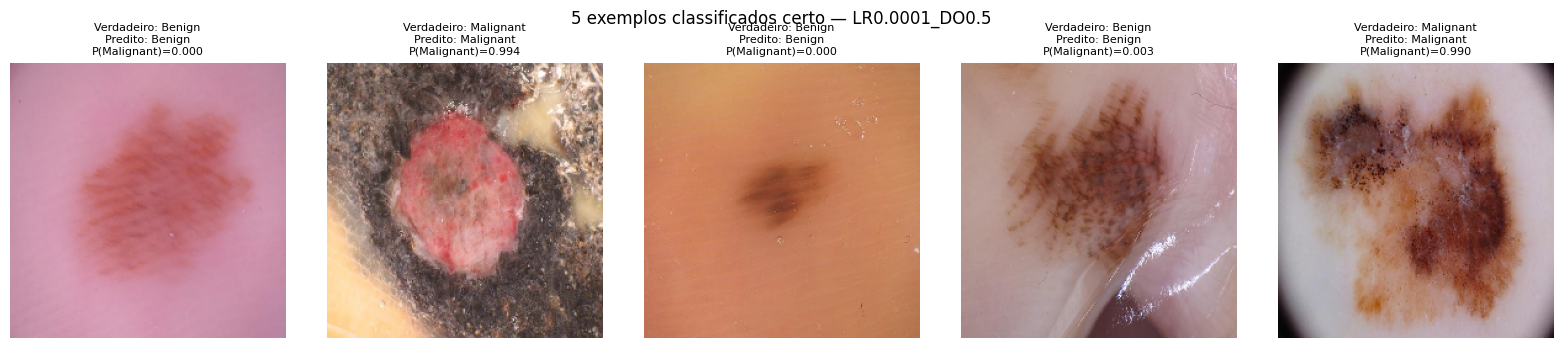

In [ ]:
# === TESTE DOS 6 MODELOS NO DATASET ISIC-IMAGES + MATRIZES DE CONFUSÃO ===
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

TAMANHO_B0   = (224, 224)
BATCH_SIZE   = 32
PASTA_MODELOS = "Modelos/treino_Modelos"

learning_rates = [1e-3, 1e-4, 1e-5]
dropouts       = [0.4, 0.5]

print("=== TESTANDO OS 6 MODELOS NO DATASET ISIC-IMAGES ===\n")

# Gerador de teste: sem augmentation e sem shuffle para preservar a ordem das labels
datagen_teste = ImageDataGenerator()
test_gen = datagen_teste.flow_from_dataframe(
    dataframe=df_isic_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

y_true       = test_gen.classes
class_labels = list(test_gen.class_indices.keys())
caminhos_img = df_isic_filtrado["caminho_imagem"].tolist()

print(f"Mapeamento de classes : {test_gen.class_indices}")
print(f"Total de amostras     : {len(y_true)}\n")

resultados_isic = {}  # nome -> {acc, recall, lr, n_unf}

# -----------------------------------------------------------------------
# Loop sobre todos os 6 modelos treinados
# -----------------------------------------------------------------------
for lr in learning_rates:
    for n_unf in unfrozen_blocks_list:

        nome_modelo    = f"LR{lr}_UL{n_unf}"
        caminho_modelo = os.path.join(PASTA_MODELOS, f"{nome_modelo}.keras")

        if not os.path.exists(caminho_modelo):
            print(f"⚠️  Modelo não encontrado: {caminho_modelo}")
            continue

        print(f"\n{'='*60}")
        print(f"📊  AVALIANDO MODELO: {nome_modelo}")
        print(f"{'='*60}")

        tf.keras.backend.clear_session()
        gc.collect()

        modelo = tf.keras.models.load_model(caminho_modelo)
        test_gen.reset()

        preds  = modelo.predict(test_gen, verbose=1)
        y_pred = (preds > 0.5).astype(int).flatten()

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        resultados_isic[nome_modelo] = {
            "acc": acc,
            "recall": rec,
            "lr": lr,
            "n_unf": n_unf,
        }

        print(f"\nRelatório de Classificação ({nome_modelo}):")
        print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
        )
        plt.title(f"Matriz de Confusão — {nome_modelo}\n(Testado em ISIC-images)")
        plt.ylabel("Real")
        plt.xlabel("Predito")
        plt.tight_layout()
        plt.show()

        del modelo
        gc.collect()

print("\n✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!")

# ========================================================================
# GRÁFICO COMPARATIVO: recall e acurácia x nº de blocos descongelados (ISIC)
# ========================================================================
if resultados_isic:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for lr in learning_rates:
        xs      = [n for n in unfrozen_blocks_list if f"LR{lr}_UL{n}" in resultados_isic]
        accs    = [resultados_isic[f"LR{lr}_UL{n}"]["acc"]    for n in xs]
        recalls = [resultados_isic[f"LR{lr}_UL{n}"]["recall"] for n in xs]

        axes[0].plot(xs, accs,    marker="o", linewidth=2, label=f"LR = {lr:.0e}")
        axes[1].plot(xs, recalls, marker="o", linewidth=2, label=f"LR = {lr:.0e}")

    axes[0].set_title("Acurácia x Nº de blocos descongelados\n(ISIC-images)")
    axes[0].set_xlabel("Nº de blocos descongelados")
    axes[0].set_ylabel("Acurácia")
    axes[0].set_xticks(unfrozen_blocks_list)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Recall x Nº de blocos descongelados\n(ISIC-images)")
    axes[1].set_xlabel("Nº de blocos descongelados")
    axes[1].set_ylabel("Recall (sensibilidade p/ Malignant)")
    axes[1].set_xticks(unfrozen_blocks_list)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    df_resumo_isic = pd.DataFrame([
        {"modelo": nome, "lr": d["lr"], "blocos_descongelados": d["n_unf"],
         "acuracia": d["acc"], "recall": d["recall"]}
        for nome, d in resultados_isic.items()
    ]).sort_values(["lr", "blocos_descongelados"]).reset_index(drop=True)
    print("\nResumo (ISIC-images):")
    print(df_resumo_isic.to_string(index=False))

    # ---- Comparação direta Validação x ISIC (se disponível) ----
    if "resultados_val" in globals() and resultados_val:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for lr in learning_rates:
            xs = unfrozen_blocks_list
            acc_val  = [resultados_val .get(f"LR{lr}_UL{n}",  {}).get("acc")    for n in xs]
            acc_isic = [resultados_isic.get(f"LR{lr}_UL{n}",  {}).get("acc")    for n in xs]
            rec_val  = [resultados_val .get(f"LR{lr}_UL{n}",  {}).get("recall") for n in xs]
            rec_isic = [resultados_isic.get(f"LR{lr}_UL{n}",  {}).get("recall") for n in xs]

            axes[0].plot(xs, acc_val,  marker="o", linestyle="-",  label=f"Val   LR={lr:.0e}")
            axes[0].plot(xs, acc_isic, marker="s", linestyle="--", label=f"ISIC  LR={lr:.0e}")
            axes[1].plot(xs, rec_val,  marker="o", linestyle="-",  label=f"Val   LR={lr:.0e}")
            axes[1].plot(xs, rec_isic, marker="s", linestyle="--", label=f"ISIC  LR={lr:.0e}")

        axes[0].set_title("Acurácia: Validação vs ISIC-images")
        axes[0].set_xlabel("Nº de blocos descongelados")
        axes[0].set_ylabel("Acurácia")
        axes[0].set_xticks(unfrozen_blocks_list)
        axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

        axes[1].set_title("Recall: Validação vs ISIC-images")
        axes[1].set_xlabel("Nº de blocos descongelados")
        axes[1].set_ylabel("Recall")
        axes[1].set_xticks(unfrozen_blocks_list)
        axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

        plt.tight_layout()
        plt.show()

# Mantemos os dicionários antigos por compatibilidade com a célula final
resultados_acc    = {k: v["acc"]    for k, v in resultados_isic.items()}
resultados_recall = {k: v["recall"] for k, v in resultados_isic.items()}

# -----------------------------------------------------------------------
# Melhor modelo (maior acurácia em ISIC-images): 5 erros e 5 acertos
# -----------------------------------------------------------------------
if not resultados_acc:
    print("Nenhum modelo foi avaliado — não há exemplos para exibir.")
else:
    melhor_nome = max(resultados_acc, key=resultados_acc.get)
    print(f"\n{'='*60}")
    print(f"🏆 Melhor modelo (acurácia em ISIC-images): {melhor_nome}")
    print(f"   Acurácia: {resultados_acc[melhor_nome]:.4f}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    gc.collect()
    modelo_melhor = tf.keras.models.load_model(
        os.path.join(PASTA_MODELOS, f"{melhor_nome}.keras")
    )
    test_gen.reset()
    probs_melhor = modelo_melhor.predict(test_gen, verbose=1)
    y_pred_melhor = (probs_melhor > 0.5).astype(int).flatten()
    del modelo_melhor
    gc.collect()

    err_idx = np.where(y_pred_melhor != y_true)[0]
    ok_idx  = np.where(y_pred_melhor == y_true)[0]

    rng = np.random.default_rng(42)
    n_err = min(5, len(err_idx))
    n_ok  = min(5, len(ok_idx))
    err_pick = rng.choice(err_idx, size=n_err, replace=False) if n_err > 0 else np.array([], dtype=int)
    ok_pick  = rng.choice(ok_idx,  size=n_ok,  replace=False) if n_ok > 0  else np.array([], dtype=int)

    def _titulo(idx):
        v = class_labels[int(y_true[idx])]
        p = class_labels[int(y_pred_melhor[idx])]
        pr_mal = float(probs_melhor[idx].ravel()[0])
        return f"Verdadeiro: {v}\nPredito: {p}\nP(Malignant)={pr_mal:.3f}"

    if n_err > 0:
        print(f"\n5 imagens classificadas ERRADO ({melhor_nome}):")
        for idx in err_pick:
            print(" ", caminhos_img[idx])
        fig, axes = plt.subplots(1, n_err, figsize=(3.2 * n_err, 3.5))
        if n_err == 1:
            axes = [axes]
        fig.suptitle(f"5 exemplos classificados errado — {melhor_nome}", fontsize=12)
        for ax, idx in zip(axes, err_pick):
            img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
            ax.imshow(img)
            ax.set_title(_titulo(idx), fontsize=8)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("(Nenhum erro no conjunto — não há 5 imagens erradas para mostrar.)")

    if n_ok > 0:
        print(f"\n5 imagens classificadas CERTO ({melhor_nome}):")
        for idx in ok_pick:
            print(" ", caminhos_img[idx])
        fig, axes = plt.subplots(1, n_ok, figsize=(3.2 * n_ok, 3.5))
        if n_ok == 1:
            axes = [axes]
        fig.suptitle(f"5 exemplos classificados certo — {melhor_nome}", fontsize=12)
        for ax, idx in zip(axes, ok_pick):
            img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
            ax.imshow(img)
            ax.set_title(_titulo(idx), fontsize=8)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("(Nenhum acerto no conjunto — não há imagens corretas para mostrar.)")


In [ ]:

# Substitua 'resultados_recall' pelo nome do dicionário onde você salvou o val_recall de cada modelo
melhor_nome = max(resultados_recall, key=resultados_recall.get)

print(f"\n{'='*60}")
print(f"🏆 Melhor modelo (Recall em ISIC-images): {melhor_nome}")
print(f"   Recall: {resultados_recall[melhor_nome]:.4f}")
print(f"{'='*60}")

tf.keras.backend.clear_session()
gc.collect()

# Carregando o modelo com o melhor Recall
modelo_melhor = tf.keras.models.load_model(
    os.path.join(PASTA_MODELOS, f"{melhor_nome}.keras")
)

test_gen.reset()
probs_melhor = modelo_melhor.predict(test_gen, verbose=1)
y_pred_melhor = (probs_melhor > 0.5).astype(int).flatten()

del modelo_melhor
gc.collect()

# Separando índices de acertos e erros
err_idx = np.where(y_pred_melhor != y_true)[0]
ok_idx  = np.where(y_pred_melhor == y_true)[0]

rng = np.random.default_rng(42)
n_err = min(5, len(err_idx))
n_ok  = min(5, len(ok_idx))
err_pick = rng.choice(err_idx, size=n_err, replace=False) if n_err > 0 else np.array([], dtype=int)
ok_pick  = rng.choice(ok_idx,  size=n_ok,  replace=False) if n_ok > 0  else np.array([], dtype=int)

def _titulo(idx):
    v = class_labels[int(y_true[idx])]
    p = class_labels[int(y_pred_melhor[idx])]
    pr_mal = float(probs_melhor[idx].ravel()[0])
    return f"Verdadeiro: {v}\nPredito: {p}\nP(Malignant)={pr_mal:.3f}"

# --- PLOTANDO OS ERROS ---
if n_err > 0:
    print(f"\n5 imagens classificadas ERRADO ({melhor_nome}):")
    for idx in err_pick:
        print(" ", caminhos_img[idx])
        
    fig, axes = plt.subplots(1, n_err, figsize=(3.2 * n_err, 3.5))
    if n_err == 1:
        axes = [axes]
    fig.suptitle(f"5 exemplos classificados errado — {melhor_nome}", fontsize=12)
    
    for ax, idx in zip(axes, err_pick):
        img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
        ax.imshow(img)
        ax.set_title(_titulo(idx), fontsize=8)
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()
else:
    print("(Nenhum erro no conjunto — não há 5 imagens erradas para mostrar.)")

# --- PLOTANDO OS ACERTOS ---
if n_ok > 0:
    print(f"\n5 imagens classificadas CERTO ({melhor_nome}):")
    for idx in ok_pick:
        print(" ", caminhos_img[idx])
        
    fig, axes = plt.subplots(1, n_ok, figsize=(3.2 * n_ok, 3.5))
    if n_ok == 1:
        axes = [axes]
    fig.suptitle(f"5 exemplos classificados certo — {melhor_nome}", fontsize=12)
    
    for ax, idx in zip(axes, ok_pick):
        img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
        ax.imshow(img)
        ax.set_title(_titulo(idx), fontsize=8)
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()
else:
    print("(Nenhum acerto no conjunto — não há imagens corretas para mostrar.)")

AttributeError: 'float' object has no attribute 'get'

## Experimento adicional — LR × Nº de blocos descongelados

Aqui treinamos **6 novos modelos** variando:
- **Learning rate** (`1e-4`, `1e-5`)
- **Nº de blocos do EfficientNetB0 descongelados** a partir do topo (`1`, `2`, `3`)
  - 1 → apenas `block7` + camadas `top_*`
  - 2 → blocos 6 e 7 + `top_*`
  - 3 → blocos 5, 6 e 7 + `top_*`

Dropout fixo em `0.4` para isolar o efeito das duas variáveis estudadas.
BatchNorm permanece congelado (boa prática em fine-tuning de EfficientNet).

Em seguida, avaliamos os 6 modelos em dois conjuntos:
1. **Validação padrão** (20% do dataset `imagens_acrais_*`).
2. **ISIC-images** (dataset externo).

Para cada conjunto, geramos um gráfico comparando **acurácia** e **val_recall** em função do número de blocos descongelados (uma curva por LR).

In [6]:
# === GRID SEARCH (6 TESTES: 2 LRs x 3 nº de blocos descongelados) ===
PASTA_MODELOS_UL = os.path.join(CAMINHO_MODELOS, "grid_unfrozen")
os.makedirs(PASTA_MODELOS_UL, exist_ok=True)

learning_rates_ul       = [1e-4, 1e-5]
unfrozen_blocks_list    = [1, 2, 3]
DROPOUT_UL              = 0.4

historicos_grid_ul = {}


def descongelar_ultimos_n_blocos(base_model, n_blocos):
    """Congela toda a base e descongela os últimos n blocos (block{7-n+1}..block7)
    junto com as camadas finais (top_*). Mantém BatchNorm congelado."""
    base_model.trainable = False
    blocos_descongelar = set(range(7 - n_blocos + 1, 8))  # ex.: n=2 -> {6,7}
    for layer in base_model.layers:
        deve_descongelar = (
            any(layer.name.startswith(f"block{b}") for b in blocos_descongelar)
            or layer.name.startswith("top_")
        )
        if deve_descongelar and not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False
    n_treinaveis = sum(int(np.prod(w.shape)) for w in base_model.trainable_weights)
    return n_treinaveis


print("=== INICIANDO GRID SEARCH (6 TESTES: LR x Nº blocos descongelados) ===")

for lr in learning_rates_ul:
    for n_unf in unfrozen_blocks_list:

        nome_teste   = f"LR{lr}_UL{n_unf}"
        nome_arquivo = os.path.join(PASTA_MODELOS_UL, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"INICIANDO TESTE: {nome_teste}")
        print(f"Learning Rate: {lr} | Blocos descongelados: {n_unf} | Dropout: {DROPOUT_UL}")
        print("=" * 60)

        tf.keras.backend.clear_session()
        gc.collect()

        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3),
        )
        n_treinaveis = descongelar_ultimos_n_blocos(base_model, n_unf)
        print(f"Parâmetros treináveis na base (sem BN): {n_treinaveis:,}")

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(DROPOUT_UL)(x)
        saida = Dense(1, activation="sigmoid")(x)
        modelo_cnn = Model(inputs=base_model.input, outputs=saida)

        modelo_cnn.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
        )

        callbacks_lista = [
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
            ModelCheckpoint(
                filepath=nome_arquivo,
                monitor="val_recall",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        ]

        print(f"Treinando modelo {nome_teste}...")
        history = modelo_cnn.fit(
            train_gen_balanced,
            validation_data=val_gen,
            epochs=20,
            callbacks=callbacks_lista,
            verbose=1,
        )
        historicos_grid_ul[nome_teste] = history.history

with open(os.path.join(PASTA_MODELOS_UL, "historicos_grid.json"), "w") as f:
    json.dump(
        {k: {m: list(map(float, v)) for m, v in h.items()} for k, h in historicos_grid_ul.items()},
        f,
    )

print("\n✅ GRID SEARCH (LR x UL) CONCLUÍDO COM SUCESSO!")
print(f"Arquivos salvos em '{PASTA_MODELOS_UL}/'.")

=== INICIANDO GRID SEARCH (6 TESTES: LR x Nº blocos descongelados) ===

INICIANDO TESTE: LR0.0001_UL1
Learning Rate: 0.0001 | Blocos descongelados: 1 | Dropout: 0.4


W0000 00:00:1778165890.891349    1293 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Parâmetros treináveis na base (sem BN): 0
Treinando modelo LR0.0001_UL1...
Epoch 1/20


I0000 00:00:1778165895.451721    1293 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8034 - loss: 0.4137 - recall: 0.7781
Epoch 1: val_recall improved from None to 0.97959, saving model to Modelos/grid_unfrozen/LR0.0001_UL1.keras

Epoch 1: finished saving model to Modelos/grid_unfrozen/LR0.0001_UL1.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.8603 - loss: 0.3240 - recall: 0.8632 - val_accuracy: 0.8978 - val_loss: 0.2458 - val_recall: 0.9796 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8988 - loss: 0.2333 - recall: 0.9264
Epoch 2: val_recall did not improve from 0.97959
98/98 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.9056 - loss: 0.2143 - recall: 0.9216 - val_accuracy: 0.9197 - val_loss: 0.1758 - val_recall: 0.9796 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9284 - loss: 0.1826 - recall: 0.9499
Epoch 3: val_recall improved from 0.97959 to 0.98980, saving model to Modelos/grid_unfrozen/LR0.0001_UL1.keras

Ep

=== AVALIAÇÃO DOS 6 MODELOS (LR x UL) NA VALIDAÇÃO PADRÃO ===

📊 AVALIANDO MODELO: LR0.0001_UL1

Relatório de Classificação (LR0.0001_UL1):
              precision    recall  f1-score   support

      Benign     1.0000    0.9329    0.9653       313
   Malignant     0.8235    1.0000    0.9032        98

    accuracy                         0.9489       411
   macro avg     0.9118    0.9665    0.9343       411
weighted avg     0.9579    0.9489    0.9505       411



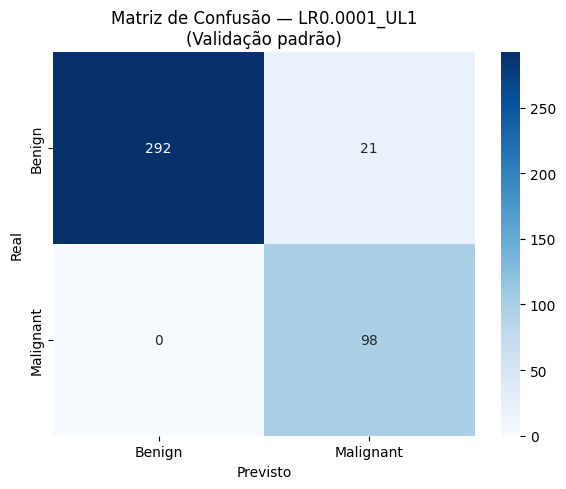


📊 AVALIANDO MODELO: LR0.0001_UL2

Relatório de Classificação (LR0.0001_UL2):
              precision    recall  f1-score   support

      Benign     1.0000    0.9457    0.9721       313
   Malignant     0.8522    1.0000    0.9202        98

    accuracy                         0.9586       411
   macro avg     0.9261    0.9728    0.9461       411
weighted avg     0.9648    0.9586    0.9597       411



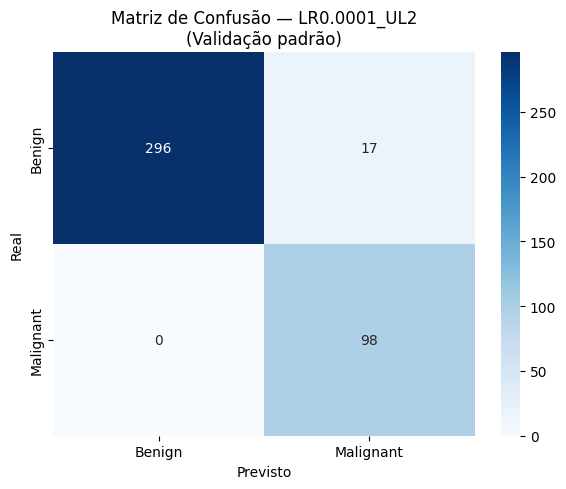


📊 AVALIANDO MODELO: LR0.0001_UL3

Relatório de Classificação (LR0.0001_UL3):
              precision    recall  f1-score   support

      Benign     1.0000    0.9073    0.9514       313
   Malignant     0.7717    1.0000    0.8711        98

    accuracy                         0.9294       411
   macro avg     0.8858    0.9537    0.9113       411
weighted avg     0.9456    0.9294    0.9323       411



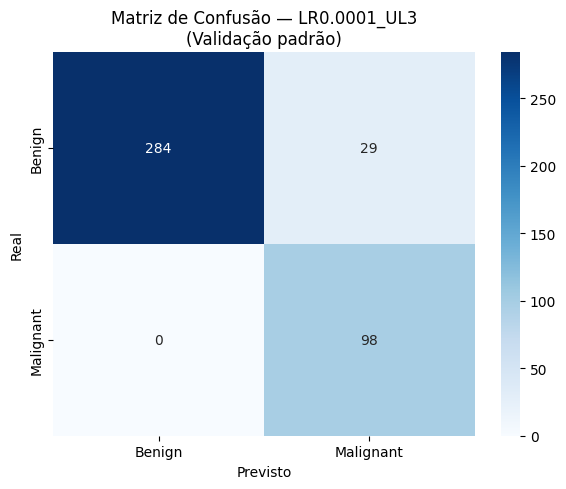


📊 AVALIANDO MODELO: LR1e-05_UL1

Relatório de Classificação (LR1e-05_UL1):
              precision    recall  f1-score   support

      Benign     0.9965    0.9042    0.9481       313
   Malignant     0.7638    0.9898    0.8622        98

    accuracy                         0.9246       411
   macro avg     0.8801    0.9470    0.9051       411
weighted avg     0.9410    0.9246    0.9276       411



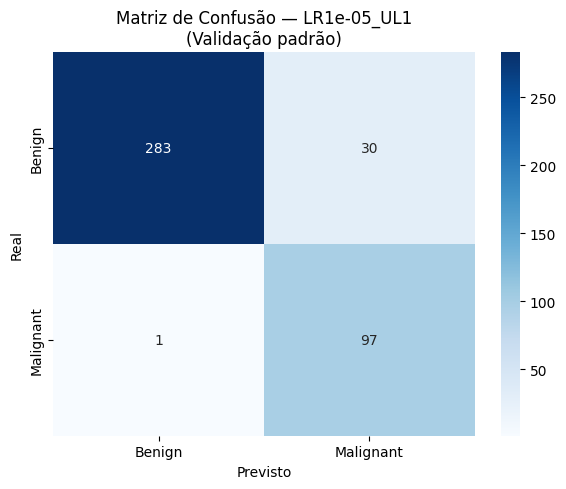


📊 AVALIANDO MODELO: LR1e-05_UL2

Relatório de Classificação (LR1e-05_UL2):
              precision    recall  f1-score   support

      Benign     1.0000    0.9105    0.9532       313
   Malignant     0.7778    1.0000    0.8750        98

    accuracy                         0.9319       411
   macro avg     0.8889    0.9553    0.9141       411
weighted avg     0.9470    0.9319    0.9345       411



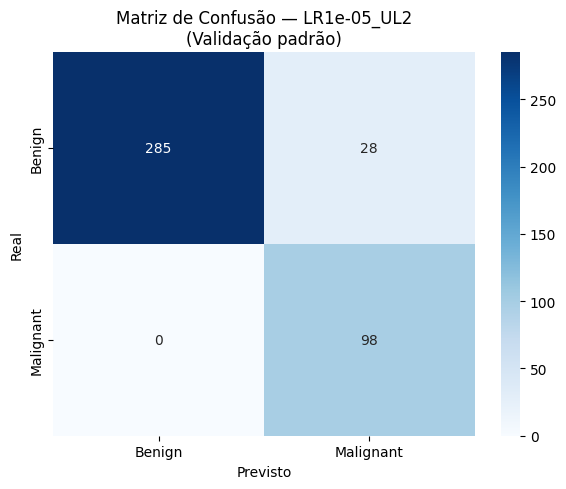


📊 AVALIANDO MODELO: LR1e-05_UL3

Relatório de Classificação (LR1e-05_UL3):
              precision    recall  f1-score   support

      Benign     1.0000    0.8882    0.9408       313
   Malignant     0.7368    1.0000    0.8485        98

    accuracy                         0.9148       411
   macro avg     0.8684    0.9441    0.8946       411
weighted avg     0.9373    0.9148    0.9188       411



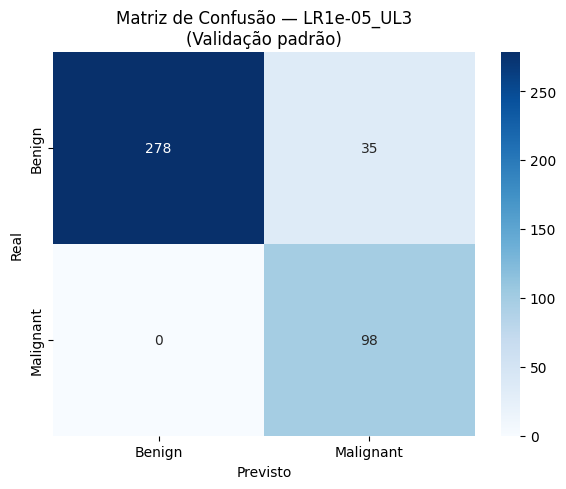

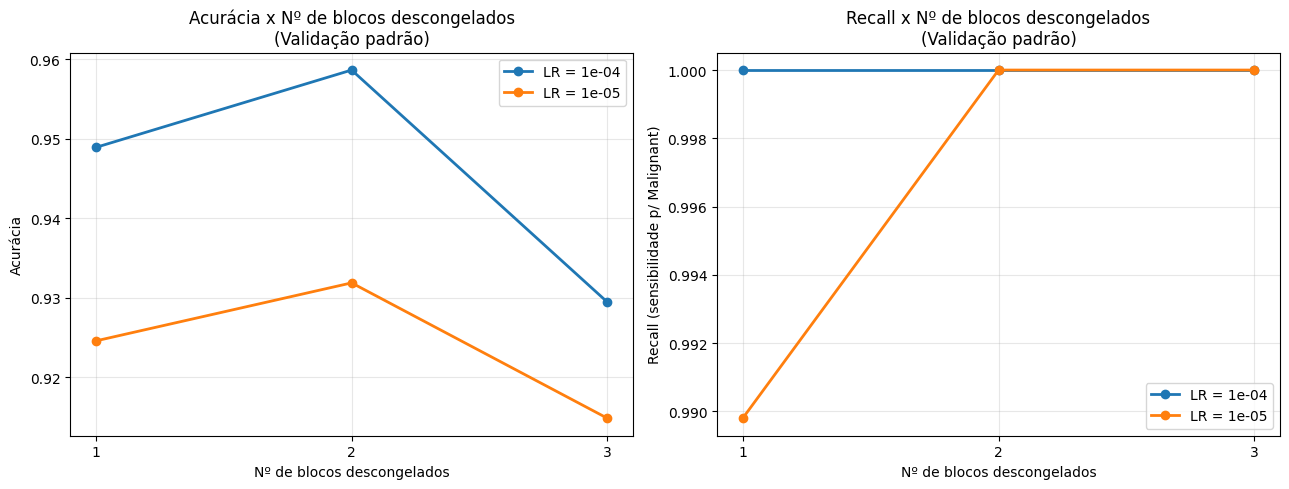


Resumo (Validação padrão):
      modelo      lr  blocos_descongelados  acuracia   recall
 LR1e-05_UL1 0.00001                     1  0.924574 0.989796
 LR1e-05_UL2 0.00001                     2  0.931873 1.000000
 LR1e-05_UL3 0.00001                     3  0.914842 1.000000
LR0.0001_UL1 0.00010                     1  0.948905 1.000000
LR0.0001_UL2 0.00010                     2  0.958637 1.000000
LR0.0001_UL3 0.00010                     3  0.929440 1.000000


In [7]:
# === AVALIAÇÃO DOS 6 NOVOS MODELOS NO CONJUNTO DE VALIDAÇÃO PADRÃO ===
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

print("=== AVALIAÇÃO DOS 6 MODELOS (LR x UL) NA VALIDAÇÃO PADRÃO ===")

y_true_val       = val_gen.classes
class_labels_val = list(val_gen.class_indices.keys())

resultados_val_ul = {}  # nome -> {acc, recall, lr, n_unf}

for lr in learning_rates_ul:
    for n_unf in unfrozen_blocks_list:
        nome_teste       = f"LR{lr}_UL{n_unf}"
        caminho_completo = os.path.join(PASTA_MODELOS_UL, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"📊 AVALIANDO MODELO: {nome_teste}")
        print("=" * 60)

        if not os.path.exists(caminho_completo):
            print(f"⚠️  Arquivo não encontrado: {caminho_completo}")
            continue

        try:
            tf.keras.backend.clear_session()
            gc.collect()

            modelo_salvo = tf.keras.models.load_model(caminho_completo)

            val_gen.reset()
            y_prob = modelo_salvo.predict(val_gen, verbose=0).flatten()
            y_pred = (y_prob > 0.5).astype(int)

            acc = accuracy_score(y_true_val, y_pred)
            rec = recall_score(y_true_val, y_pred)
            resultados_val_ul[nome_teste] = {
                "acc": acc,
                "recall": rec,
                "lr": lr,
                "n_unf": n_unf,
            }

            print(f"\nRelatório de Classificação ({nome_teste}):")
            print(classification_report(y_true_val, y_pred, target_names=class_labels_val, digits=4, zero_division=0))

            cm = confusion_matrix(y_true_val, y_pred)
            plt.figure(figsize=(6, 5))
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels_val, yticklabels=class_labels_val,
            )
            plt.title(f"Matriz de Confusão — {nome_teste}\n(Validação padrão)")
            plt.ylabel("Real")
            plt.xlabel("Previsto")
            plt.tight_layout()
            plt.show()

            del modelo_salvo
            tf.keras.backend.clear_session()
            gc.collect()

        except (FileNotFoundError, ValueError) as e:
            print(f"⚠️  Falha ao carregar/avaliar {caminho_completo}: {e}")

# ========================================================================
# GRÁFICO COMPARATIVO: val_recall e acurácia x nº de blocos descongelados
# ========================================================================
if resultados_val_ul:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for lr in learning_rates_ul:
        xs       = [n for n in unfrozen_blocks_list if f"LR{lr}_UL{n}" in resultados_val_ul]
        accs     = [resultados_val_ul[f"LR{lr}_UL{n}"]["acc"]    for n in xs]
        recalls  = [resultados_val_ul[f"LR{lr}_UL{n}"]["recall"] for n in xs]

        axes[0].plot(xs, accs,    marker="o", linewidth=2, label=f"LR = {lr:.0e}")
        axes[1].plot(xs, recalls, marker="o", linewidth=2, label=f"LR = {lr:.0e}")

    axes[0].set_title("Acurácia x Nº de blocos descongelados\n(Validação padrão)")
    axes[0].set_xlabel("Nº de blocos descongelados")
    axes[0].set_ylabel("Acurácia")
    axes[0].set_xticks(unfrozen_blocks_list)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Recall x Nº de blocos descongelados\n(Validação padrão)")
    axes[1].set_xlabel("Nº de blocos descongelados")
    axes[1].set_ylabel("Recall (sensibilidade p/ Malignant)")
    axes[1].set_xticks(unfrozen_blocks_list)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    df_resumo_val_ul = pd.DataFrame([
        {"modelo": nome, "lr": d["lr"], "blocos_descongelados": d["n_unf"],
         "acuracia": d["acc"], "recall": d["recall"]}
        for nome, d in resultados_val_ul.items()
    ]).sort_values(["lr", "blocos_descongelados"]).reset_index(drop=True)
    print("\nResumo (Validação padrão):")
    print(df_resumo_val_ul.to_string(index=False))
else:
    print("⚠️  Nenhum modelo avaliado. Verifique se os arquivos .keras existem.")

=== TESTANDO OS 6 MODELOS (LR x UL) NO DATASET ISIC-IMAGES ===

Found 666 validated image filenames belonging to 2 classes.
Mapeamento de classes : {'Benign': 0, 'Malignant': 1}
Total de amostras     : 666


📊  AVALIANDO MODELO: LR0.0001_UL1
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step

Relatório de Classificação (LR0.0001_UL1):
              precision    recall  f1-score   support

      Benign     0.9350    0.9368    0.9359       522
   Malignant     0.7692    0.7639    0.7666       144

    accuracy                         0.8994       666
   macro avg     0.8521    0.8503    0.8512       666
weighted avg     0.8992    0.8994    0.8993       666



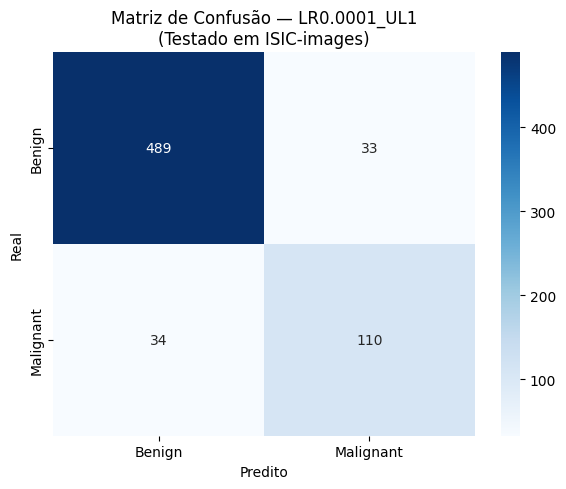


📊  AVALIANDO MODELO: LR0.0001_UL2
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step

Relatório de Classificação (LR0.0001_UL2):
              precision    recall  f1-score   support

      Benign     0.9369    0.9387    0.9378       522
   Malignant     0.7762    0.7708    0.7735       144

    accuracy                         0.9024       666
   macro avg     0.8566    0.8548    0.8557       666
weighted avg     0.9022    0.9024    0.9023       666



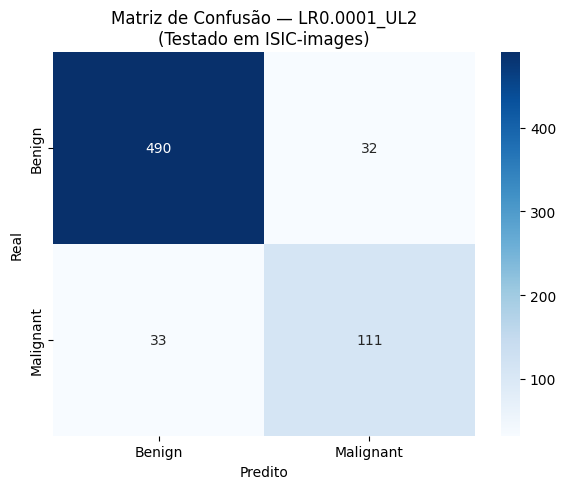


📊  AVALIANDO MODELO: LR0.0001_UL3
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step

Relatório de Classificação (LR0.0001_UL3):
              precision    recall  f1-score   support

      Benign     0.9508    0.9253    0.9379       522
   Malignant     0.7532    0.8264    0.7881       144

    accuracy                         0.9039       666
   macro avg     0.8520    0.8758    0.8630       666
weighted avg     0.9081    0.9039    0.9055       666



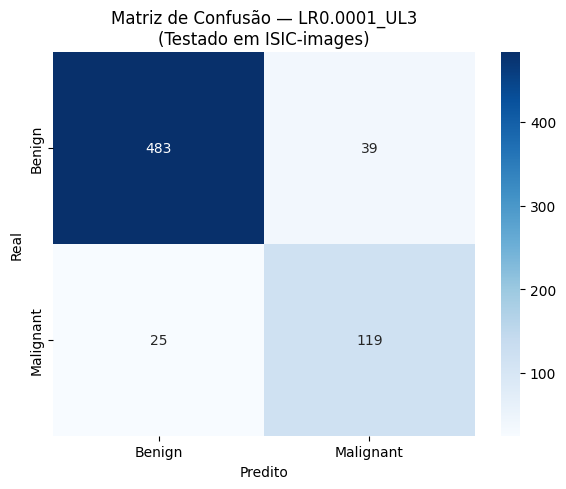


📊  AVALIANDO MODELO: LR1e-05_UL1
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step

Relatório de Classificação (LR1e-05_UL1):
              precision    recall  f1-score   support

      Benign     0.9253    0.9023    0.9137       522
   Malignant     0.6752    0.7361    0.7043       144

    accuracy                         0.8664       666
   macro avg     0.8003    0.8192    0.8090       666
weighted avg     0.8712    0.8664    0.8684       666



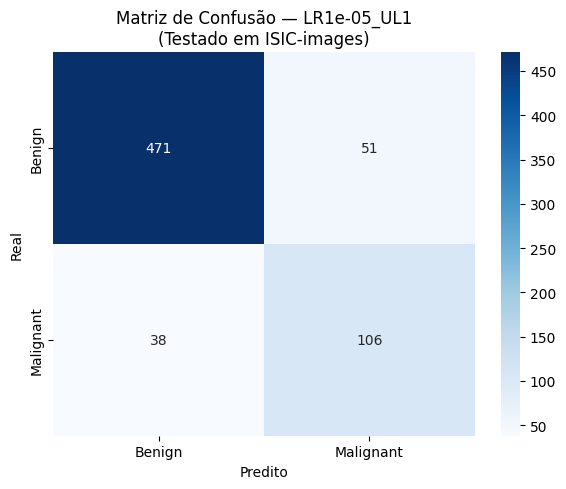


📊  AVALIANDO MODELO: LR1e-05_UL2
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step

Relatório de Classificação (LR1e-05_UL2):
              precision    recall  f1-score   support

      Benign     0.9322    0.9215    0.9268       522
   Malignant     0.7267    0.7569    0.7415       144

    accuracy                         0.8859       666
   macro avg     0.8294    0.8392    0.8341       666
weighted avg     0.8877    0.8859    0.8867       666



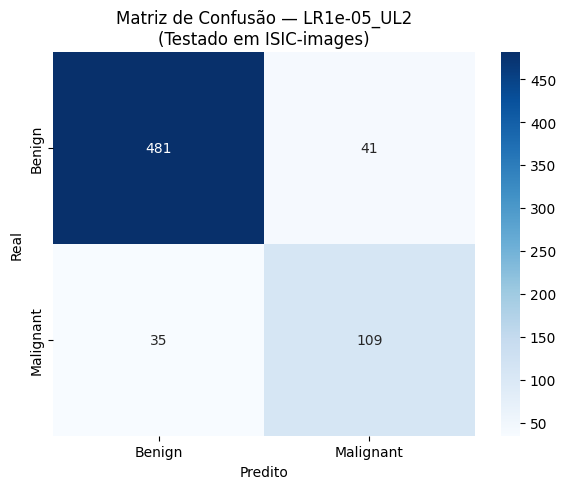


📊  AVALIANDO MODELO: LR1e-05_UL3
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step

Relatório de Classificação (LR1e-05_UL3):
              precision    recall  f1-score   support

      Benign     0.9402    0.8736    0.9057       522
   Malignant     0.6354    0.7986    0.7077       144

    accuracy                         0.8574       666
   macro avg     0.7878    0.8361    0.8067       666
weighted avg     0.8743    0.8574    0.8629       666



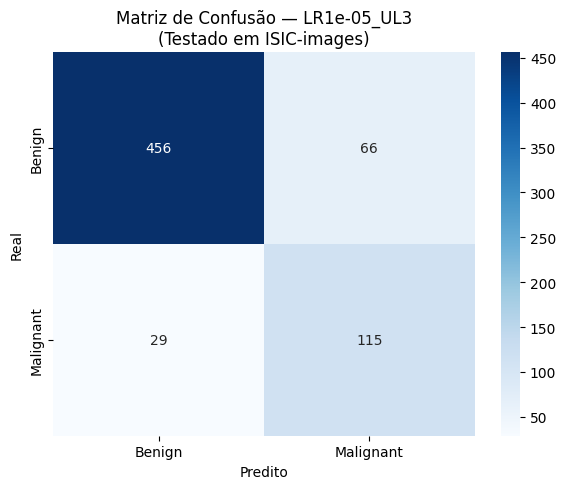


✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!


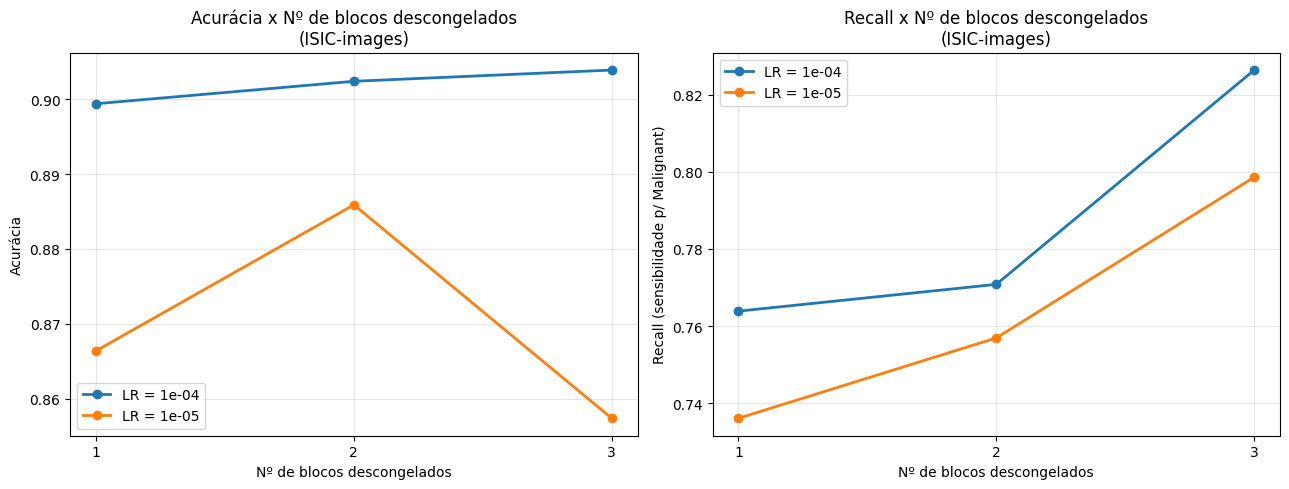


Resumo (ISIC-images):
      modelo      lr  blocos_descongelados  acuracia   recall
 LR1e-05_UL1 0.00001                     1  0.866366 0.736111
 LR1e-05_UL2 0.00001                     2  0.885886 0.756944
 LR1e-05_UL3 0.00001                     3  0.857357 0.798611
LR0.0001_UL1 0.00010                     1  0.899399 0.763889
LR0.0001_UL2 0.00010                     2  0.902402 0.770833
LR0.0001_UL3 0.00010                     3  0.903904 0.826389


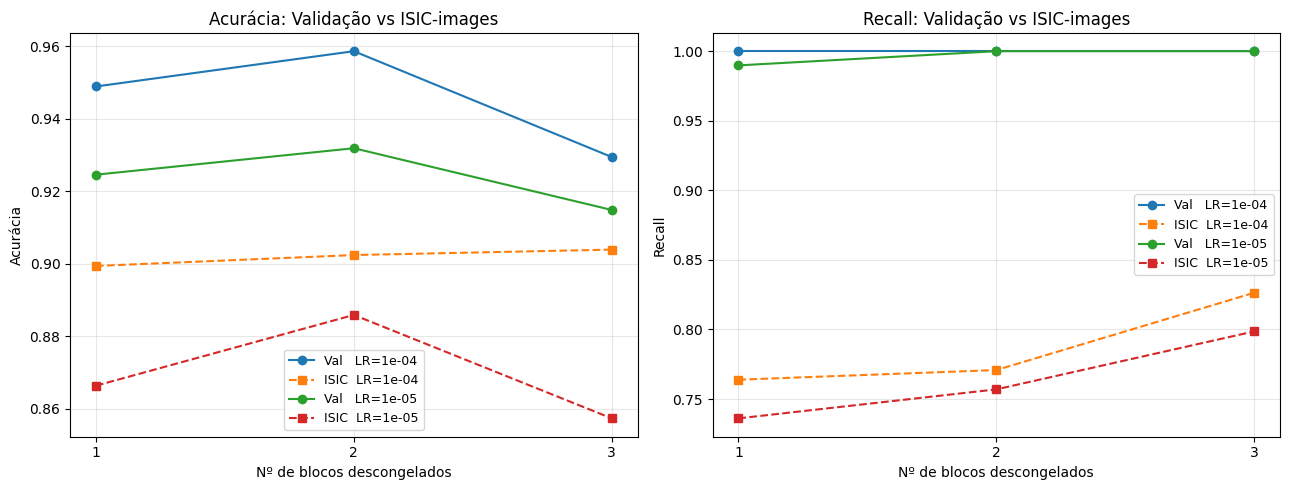

In [8]:
# === AVALIAÇÃO DOS 6 NOVOS MODELOS NO DATASET ISIC-IMAGES ===
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

print("=== TESTANDO OS 6 MODELOS (LR x UL) NO DATASET ISIC-IMAGES ===\n")

datagen_teste_ul = ImageDataGenerator()
test_gen_ul = datagen_teste_ul.flow_from_dataframe(
    dataframe=df_isic_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

y_true_isic       = test_gen_ul.classes
class_labels_isic = list(test_gen_ul.class_indices.keys())

print(f"Mapeamento de classes : {test_gen_ul.class_indices}")
print(f"Total de amostras     : {len(y_true_isic)}\n")

resultados_isic_ul = {}  # nome -> {acc, recall, lr, n_unf}

for lr in learning_rates_ul:
    for n_unf in unfrozen_blocks_list:

        nome_modelo    = f"LR{lr}_UL{n_unf}"
        caminho_modelo = os.path.join(PASTA_MODELOS_UL, f"{nome_modelo}.keras")

        if not os.path.exists(caminho_modelo):
            print(f"⚠️  Modelo não encontrado: {caminho_modelo}")
            continue

        print(f"\n{'='*60}")
        print(f"📊  AVALIANDO MODELO: {nome_modelo}")
        print(f"{'='*60}")

        tf.keras.backend.clear_session()
        gc.collect()

        modelo = tf.keras.models.load_model(caminho_modelo)
        test_gen_ul.reset()

        preds  = modelo.predict(test_gen_ul, verbose=1)
        y_pred = (preds > 0.5).astype(int).flatten()

        acc = accuracy_score(y_true_isic, y_pred)
        rec = recall_score(y_true_isic, y_pred)
        resultados_isic_ul[nome_modelo] = {
            "acc": acc, "recall": rec, "lr": lr, "n_unf": n_unf,
        }

        print(f"\nRelatório de Classificação ({nome_modelo}):")
        print(classification_report(y_true_isic, y_pred, target_names=class_labels_isic, digits=4))

        cm = confusion_matrix(y_true_isic, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels_isic, yticklabels=class_labels_isic,
        )
        plt.title(f"Matriz de Confusão — {nome_modelo}\n(Testado em ISIC-images)")
        plt.ylabel("Real")
        plt.xlabel("Predito")
        plt.tight_layout()
        plt.show()

        del modelo
        gc.collect()

print("\n✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!")

# ========================================================================
# GRÁFICO COMPARATIVO: recall e acurácia x nº de blocos descongelados (ISIC)
# ========================================================================
if resultados_isic_ul:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for lr in learning_rates_ul:
        xs      = [n for n in unfrozen_blocks_list if f"LR{lr}_UL{n}" in resultados_isic_ul]
        accs    = [resultados_isic_ul[f"LR{lr}_UL{n}"]["acc"]    for n in xs]
        recalls = [resultados_isic_ul[f"LR{lr}_UL{n}"]["recall"] for n in xs]

        axes[0].plot(xs, accs,    marker="o", linewidth=2, label=f"LR = {lr:.0e}")
        axes[1].plot(xs, recalls, marker="o", linewidth=2, label=f"LR = {lr:.0e}")

    axes[0].set_title("Acurácia x Nº de blocos descongelados\n(ISIC-images)")
    axes[0].set_xlabel("Nº de blocos descongelados")
    axes[0].set_ylabel("Acurácia")
    axes[0].set_xticks(unfrozen_blocks_list)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Recall x Nº de blocos descongelados\n(ISIC-images)")
    axes[1].set_xlabel("Nº de blocos descongelados")
    axes[1].set_ylabel("Recall (sensibilidade p/ Malignant)")
    axes[1].set_xticks(unfrozen_blocks_list)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    df_resumo_isic_ul = pd.DataFrame([
        {"modelo": nome, "lr": d["lr"], "blocos_descongelados": d["n_unf"],
         "acuracia": d["acc"], "recall": d["recall"]}
        for nome, d in resultados_isic_ul.items()
    ]).sort_values(["lr", "blocos_descongelados"]).reset_index(drop=True)
    print("\nResumo (ISIC-images):")
    print(df_resumo_isic_ul.to_string(index=False))

    # ---- Comparação direta Validação x ISIC ----
    if "resultados_val_ul" in globals() and resultados_val_ul:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for lr in learning_rates_ul:
            xs = unfrozen_blocks_list
            acc_val  = [resultados_val_ul .get(f"LR{lr}_UL{n}", {}).get("acc")    for n in xs]
            acc_isic = [resultados_isic_ul.get(f"LR{lr}_UL{n}", {}).get("acc")    for n in xs]
            rec_val  = [resultados_val_ul .get(f"LR{lr}_UL{n}", {}).get("recall") for n in xs]
            rec_isic = [resultados_isic_ul.get(f"LR{lr}_UL{n}", {}).get("recall") for n in xs]

            axes[0].plot(xs, acc_val,  marker="o", linestyle="-",  label=f"Val   LR={lr:.0e}")
            axes[0].plot(xs, acc_isic, marker="s", linestyle="--", label=f"ISIC  LR={lr:.0e}")
            axes[1].plot(xs, rec_val,  marker="o", linestyle="-",  label=f"Val   LR={lr:.0e}")
            axes[1].plot(xs, rec_isic, marker="s", linestyle="--", label=f"ISIC  LR={lr:.0e}")

        axes[0].set_title("Acurácia: Validação vs ISIC-images")
        axes[0].set_xlabel("Nº de blocos descongelados")
        axes[0].set_ylabel("Acurácia")
        axes[0].set_xticks(unfrozen_blocks_list)
        axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

        axes[1].set_title("Recall: Validação vs ISIC-images")
        axes[1].set_xlabel("Nº de blocos descongelados")
        axes[1].set_ylabel("Recall")
        axes[1].set_xticks(unfrozen_blocks_list)
        axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

        plt.tight_layout()
        plt.show()